In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [4]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [5]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [6]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [7]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [8]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [9]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Синонимы и антонимы

In [10]:
c2_syn = pd.read_csv('c2_augmented_synonyms.csv')
c2_ant = pd.read_csv('c2_augmented_antonyms.csv')
c2 = pd.concat([c2_syn, c2_ant], axis=0, ignore_index=True)
c2

,Unnamed: 0,text,augmented-text
0,0,"3:38–3:54 Собственно, сама по себе радиация не...","3: 38 – 3: 54 Собственно, сама по себе радиаци..."
1,1,Недавно компания Uber объявила об инвестиции о...,Недавно фирма Uber объявила об инвестиции одно...
2,2,"Множество повестей: «Двойник», «Дядюшкин сон»,...","Множество повестей: «Двойник», «Дядюшкин сон»,..."
3,3,Встречи одноклассников и одногруппников превра...,Встречи одноклассников и одногруппников преобр...
4,4,Самопрезентация — как главная черта времени и ...,Самопрезентация — как основная грань времени и...
...,...,...,...
185,66,"При этом определение того, что является «разум...","При этом определение того, что является «бессм..."
186,67,"От одного банана — в два раза больше (0,1), а ...","От одного банана — в два раза больше (0, 1), а..."
187,68,00:00:24 А сегодня испытания. 13 участников. Ж...,00: 00: 24 А сегодня испытания. 13 участников....
188,69,«Прома» способна предложить дилерам вполне бож...,«Прома» способна предложить дилерам вполне бож...


In [11]:
model, val_dataset, train_time = fit(c2)

config.json:   0%|          | 0.00/591 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6047
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.966700,0.967877
2,0.503000,0.983057
3,0.150100,1.356176


Обучение завершено за 325.86 секунд (0:05:25)


In [12]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6137
F1 Micro: 0.6137
F1 Macro: 0.6054
F1 Weighted: 0.6129
MAE: 0.4799
              precision    recall  f1-score   support

           1       0.72      0.83      0.77       153
           2       0.66      0.57      0.61       227
           3       0.67      0.57      0.62       475
           4       0.57      0.55      0.56       343
           5       0.52      0.70      0.60       237
           6       0.45      0.50      0.48        30

    accuracy                           0.61      1465
   macro avg       0.60      0.62      0.61      1465
weighted avg       0.62      0.61      0.61      1465



0.6137
0.6137
0.6054
0.6129
0.4799
325.86


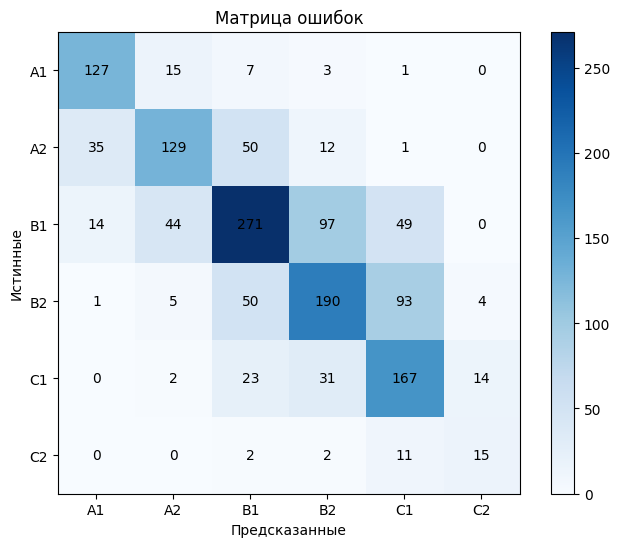

In [13]:
visualize_cm(true_labels, predictions)